In [16]:
import numpy as np
import scipy.signal as signal
import scipy.io.wavfile as wavfile
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

# Plotly Design
pio.templates.default = "plotly_white"

# --- HILFSFUNKTION 1: Testsignal generieren ---
def get_test_signal(fs=100.0, duration=5.0):
    """Erzeugt das synthetische Misch-Signal aus der Aufgabe."""
    t = np.arange(0, duration, 1/fs)
    f_base = 1.0
    sig = (1.0 * np.cos(2 * np.pi * 1 * f_base * t) + 
           0.2 * np.cos(2 * np.pi * 5 * f_base * t + np.pi/3) + 
           0.5 * np.cos(2 * np.pi * 20 * f_base * t - np.pi/4) + 
           1.0 * np.cos(2 * np.pi * 42 * f_base * t))
    return t, sig

# --- HILFSFUNKTION 2: Standard-Plot für Frequenzgänge ---
def plot_frequency_responses(w, H_list, names, title="Frequenzgang"):
    """Plottet mehrere Frequenzgänge in ein Diagramm."""
    fig = go.Figure()
    colors = ['blue', 'red', 'green', 'purple', 'orange']
    
    for i, H in enumerate(H_list):
        color = colors[i % len(colors)]
        fig.add_trace(go.Scatter(x=w, y=np.abs(H), mode='lines', name=names[i], line=dict(color=color)))
        
    fig.update_layout(title=title, xaxis_title="Frequenz [0...π]", yaxis_title="|H(ω)|",
                      xaxis=dict(range=[0, np.pi]), width=800, height=500)
    fig.show()

# --- HILFSFUNKTION 3: Die große 2x2 Analyse ---
def plot_signal_analysis(t, sig_orig, sig_filt, fs, title="Signalanalyse"):
    """
    Erstellt den 2x2 Plot (Original vs. Filter, Zeit vs. Frequenz).
    Berechnet die FFT automatisch intern.
    """
    # FFT Berechnung
    N = len(sig_orig)
    freq_axis = np.arange(N) * fs / N
    fft_orig = np.abs(np.fft.fft(sig_orig)) / N
    fft_filt = np.abs(np.fft.fft(sig_filt)) / N
    
    # Performance-Optimierung für große Signale (z.B. Audio)
    ScatterType = go.Scattergl if len(t) > 5000 else go.Scatter
    
    fig = make_subplots(rows=2, cols=2, vertical_spacing=0.15,
                        subplot_titles=("Original (Zeit)", "Original Spektrum (log)", 
                                        "Gefiltert (Zeit)", "Gefiltert Spektrum (log)"))
    
    # Zeitbereich
    fig.add_trace(ScatterType(x=t, y=sig_orig, name="Original", line=dict(color='blue')), row=1, col=1)
    fig.add_trace(ScatterType(x=t, y=sig_filt, name="Gefiltert", line=dict(color='blue')), row=2, col=1)
    
    # Frequenzbereich
    fig.add_trace(ScatterType(x=freq_axis, y=fft_orig, name="Spektrum Orig", line=dict(color='orange')), row=1, col=2)
    fig.add_trace(ScatterType(x=freq_axis, y=fft_filt, name="Spektrum Filt", line=dict(color='orange')), row=2, col=2)
    
    # Layout
    fig.update_layout(height=800, width=1000, title_text=title, showlegend=False)
    
    # Achsenbeschriftung & Log-Skala
    for r in [1, 2]:
        fig.update_xaxes(title_text="t [s]", row=r, col=1)
        fig.update_xaxes(title_text="f [Hz]", row=r, col=2)
        fig.update_yaxes(type="log", title_text="|F(jω)|", row=r, col=2)
        # Optional: Zoom auf relevante Frequenzen (0 bis fs/2)
        fig.update_xaxes(range=[0, fs/2], row=r, col=2)

    fig.show()

# a) Polynomfilter 1. Ordnung

(entspricht dem Polynomfilter 0. Ordnung bei symmetrischem Fit)

Aus der Vorlesung:

- Polynomfilter 0. Ordnung, 'Boxcar Filter': Für m Berechnungspunkte:
\begin{equation}
x_n = \frac{1}{m_1}
\end{equation}

- Bei Polynom 1. Ordnung wäre die zu minimierende Gleichung: F(A,B)=∑m​[xm​−(A+B⋅m)]2
\begin{equation}
F(A,B) = \sum_m [x_m - (A + B \cdot m)]^2
\end{equation}

- Mit $\partial F / \partial A = \partial F / \partial B = 0$ ergibt sich für einen symmetrischen Fit genau wie beim Boxcar für $m$ Berechnungspunkte:
\begin{equation}
A = x_n = \frac{1}{m_1} \sum_m x_{n-m}
\end{equation}

- Es wird nur der Koeffizient $A$ gebraucht, da für jedes Polynom gilt $f(t=0)=A$ und wir den (symmetrischen) Mittelpunkt des Polynomfits suchen.

Testsignal: $x(n)=e^{j \omega n}$ ist ein "Mischsignal" und bewirkt den Übergang zum Frequenzbereich.

## Teil 1:Frequenzgang des Boxfilters

Hier analysieren wir Boxfilter mit unterschiedlichen Fenstergrößen (3, 5, 7 Punkte) im Frequenzbereich.

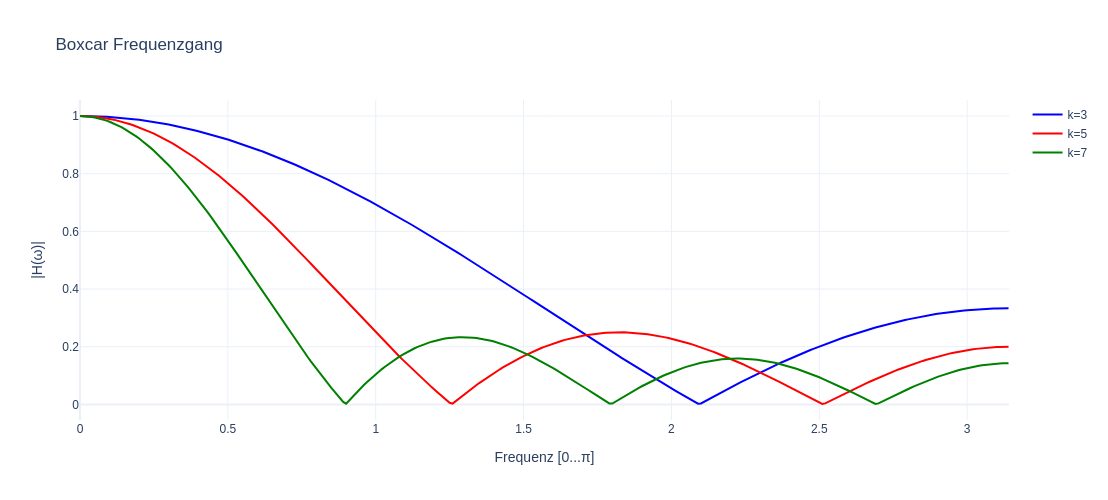

In [19]:
n_ranges = [np.arange(-1, 2), np.arange(-2, 3), np.arange(-3, 4)] # k=3, 5, 7
w = np.arange(0, np.pi, 0.01)
H_list = []

for n_vec in n_ranges:
    # Formel: 1/N * sum(exp(j * w * n))
    term = np.exp(1j * w[:, None] * n_vec[None, :])
    H_list.append((1 / len(n_vec)) * np.sum(term, axis=1))

plot_frequency_responses(w, H_list, ['k=3', 'k=5', 'k=7'], "Boxcar Frequenzgang")

## Teil 2: Auswirkung auf ein Misch-Sinus-Testsignal

Anwendung eines Boxcar-Filters mit 5 Berechnungspunkten auf ein zusammengesetztes Signal.

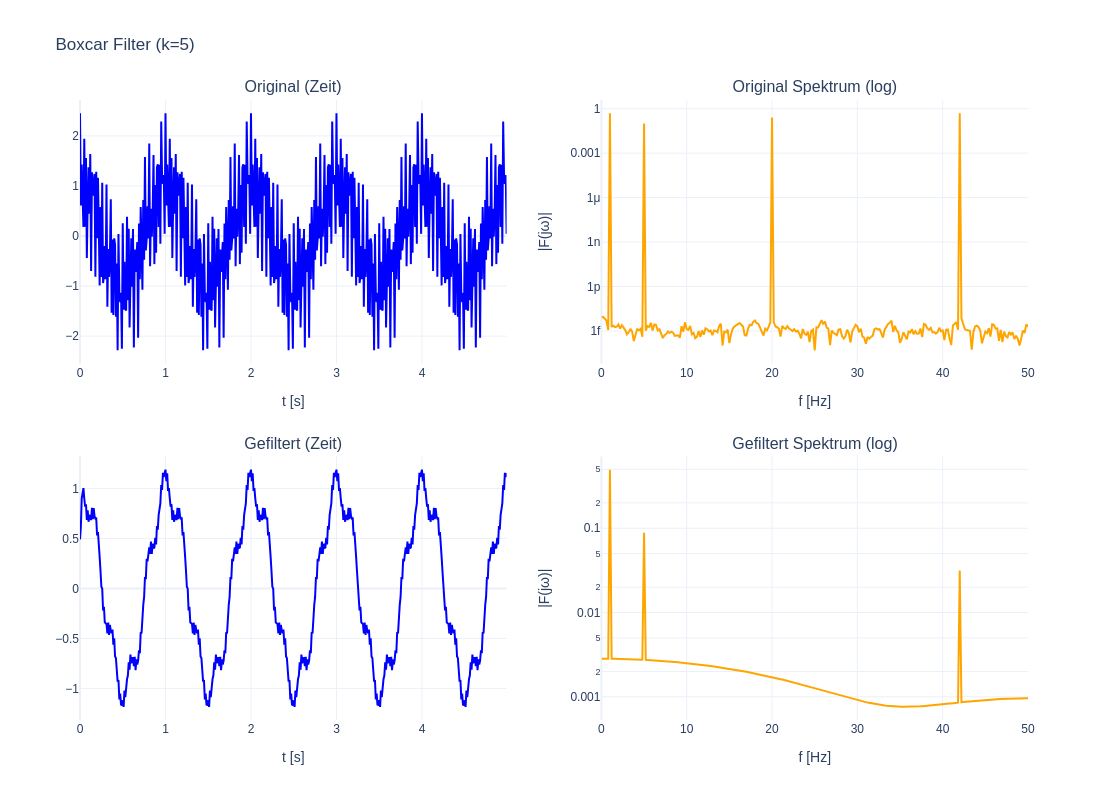

In [18]:
fs = 100.0
t, sig = get_test_signal(fs)

# Boxcar Filter Länge 5
b = np.ones(5) / 5
sig_filtered = signal.lfilter(b, 1, sig)

plot_signal_analysis(t, sig, sig_filtered, fs, "Boxcar Filter (k=5)")

# b) Polynomfilter 2. Ordnung

Aus der Vorlesung:

Die Berechnungsformel für den Koeffizienten A (geglätteter Wert) bei einem Polynomfit 2. Ordnung lautet:
\begin{equation}
A = \frac{ \sum_m m^4 \cdot \sum_m x_m - \sum_m m^2 \cdot \sum_m m^2 x_m }{ \sum_m 1 \cdot \sum_m m^4 - (\sum_m m^2)^2 }
\end{equation}

- $m$ sind die Indizes des Fensters (z.B. $-3, -2, -1, 0, 1, 2, 3$).
- Wie bei Teil a) dient $x(n)=e^{j \omega n}$ zum direkten Übergang in den Frequenzbereich für die Analyse.

## Teil 1: Frequenzgang des Polynomfilters 2. Ordnung

Wir analysieren Filter mit unterschiedlichen Fenstergrößen (5, 7, 9 Punkte).

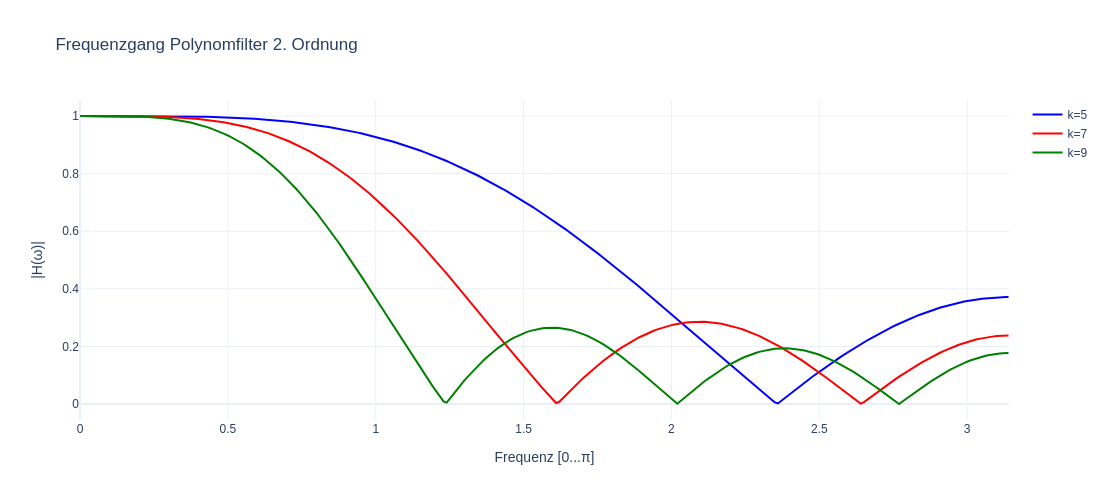

In [24]:
m_ranges = [np.arange(-2, 3), np.arange(-3, 4), np.arange(-4, 5)] # k=5, 7, 9
labels = ['k=5', 'k=7', 'k=9']
w = np.arange(0, np.pi, 0.01)

H_list_b = []

for m_vec in m_ranges:
    # Broadcasting Vorbereitung: x = exp(j * w * m)
    # w: (W,), m_vec: (M,) -> x: (W, M)
    x = np.exp(1j * w[:, None] * m_vec[None, :])
    
    # Terme vorbereiten
    m2x = x * (m_vec[None, :] ** 2) # x * m^2
    sum_m4 = np.sum(m_vec**4)
    sum_m2 = np.sum(m_vec**2)
    sum_1  = len(m_vec)
    
    # Zähler und Nenner der Formel
    numerator = sum_m4 * np.sum(x, axis=1) - sum_m2 * np.sum(m2x, axis=1)
    denominator = sum_1 * sum_m4 - sum_m2**2
    
    H_list_b.append(numerator / denominator)

# Plotten mit unserer Hilfsfunktion
plot_frequency_responses(w, H_list_b, labels, "Frequenzgang Polynomfilter 2. Ordnung")

## Teil 2: Auswirkung auf ein Misch-Sinus-Testsignal

Anwendung des Polynomfilters 2. Ordnung mit 7 Berechnungspunkten ($m \in (−3…3)$).

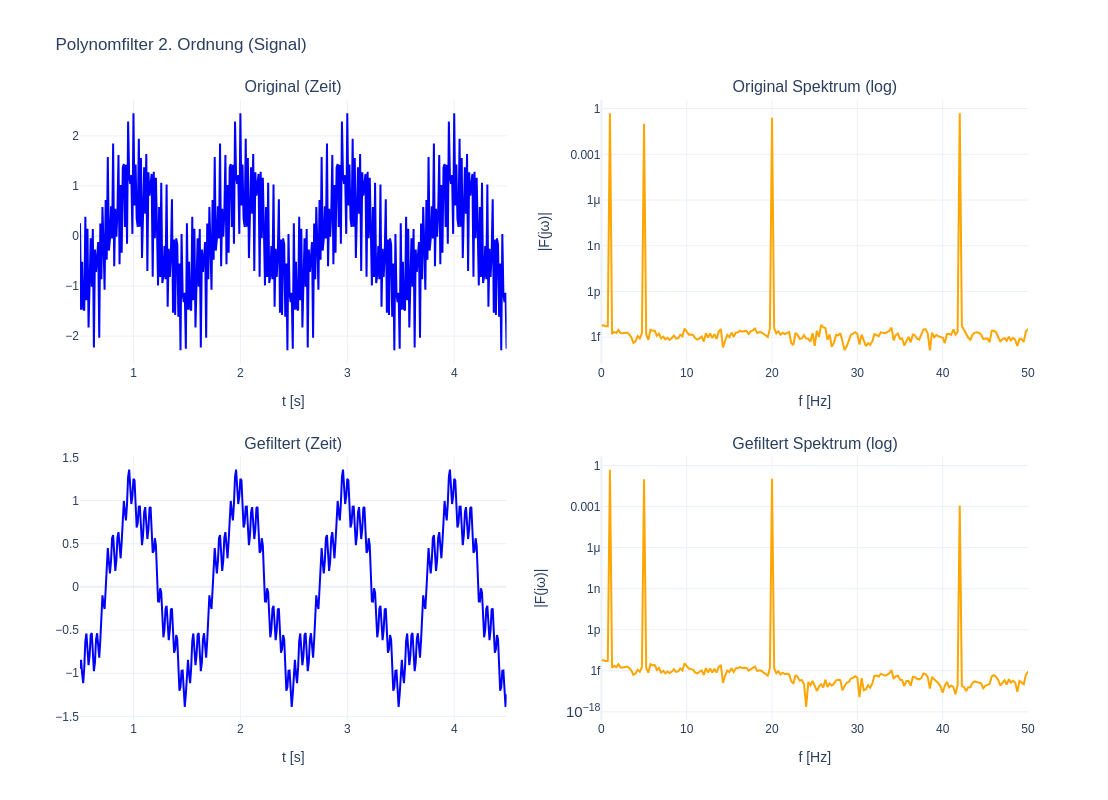

In [25]:
def apply_poly_filter_manual(sig, radius=3):
    """
    Wendet den Polynomfilter (2. Ordnung) manuell an.
    radius=3 bedeutet Fenster von -3 bis +3 (Länge 7).
    """
    m_vec = np.arange(-radius, radius + 1)
    sum_m4 = np.sum(m_vec**4)
    sum_m2 = np.sum(m_vec**2)
    denom = len(m_vec) * sum_m4 - sum_m2**2
    
    sig_out = np.zeros_like(sig)
    
    # Loop über das Signal (analog zur MATLAB Logik)
    # Wir starten bei 'radius' und enden 'radius' vor Schluss
    for k in range(radius, len(sig) - radius):
        # Das Fenster aus dem Signal schneiden
        window = sig[k-radius : k+radius+1]
        
        term1 = sum_m4 * np.sum(window)
        term2 = sum_m2 * np.sum(m_vec**2 * window)
        
        sig_out[k] = (term1 - term2) / denom
        
    return sig_out

# Testsignal holen
fs = 100.0
t, sig = get_test_signal(fs)

# Filter anwenden (k=7 entspricht Radius 3)
radius = 3
sig_poly_filt = apply_poly_filter_manual(sig, radius=radius)

# Randbereiche abschneiden für sauberen Plot (Slicing)
# Wir schneiden vorne und hinten 50 Punkte ab, um Einschwingvorgänge auszublenden
cut = 50
t_cut = t[cut:-cut]
sig_cut = sig[cut:-cut]
filt_cut = sig_poly_filt[cut:-cut]

# Analyse Plotten
plot_signal_analysis(t_cut, sig_cut, filt_cut, fs, "Polynomfilter 2. Ordnung (Signal)")

# c) Gauß-Filter

Das Gauß-Filter ist ein Glättungsfilter, dessen Impulsantwort einer Gaußschen Glockenkurve entspricht. Es hat den Vorteil, dass es sowohl im Zeit- als auch im Frequenzbereich "gutmütig" verläuft (kein Überschwingen im Zeitbereich, minimales Produkt aus Zeit- und Bandbreite).

- Sigma ($\sigma$): Bestimmt die Breite der Glockenkurve.
- Impulsantwort: Wir betrachten Filterlängen von 5, 7 und 9 Punkten.

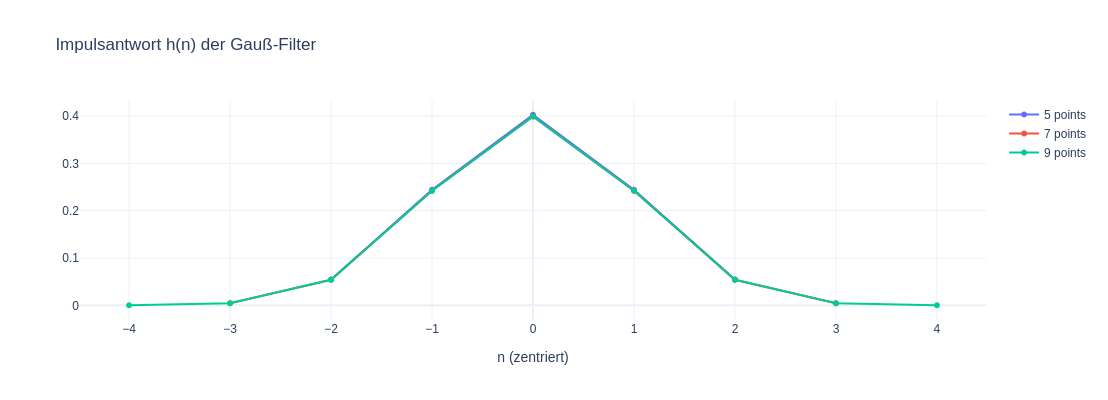

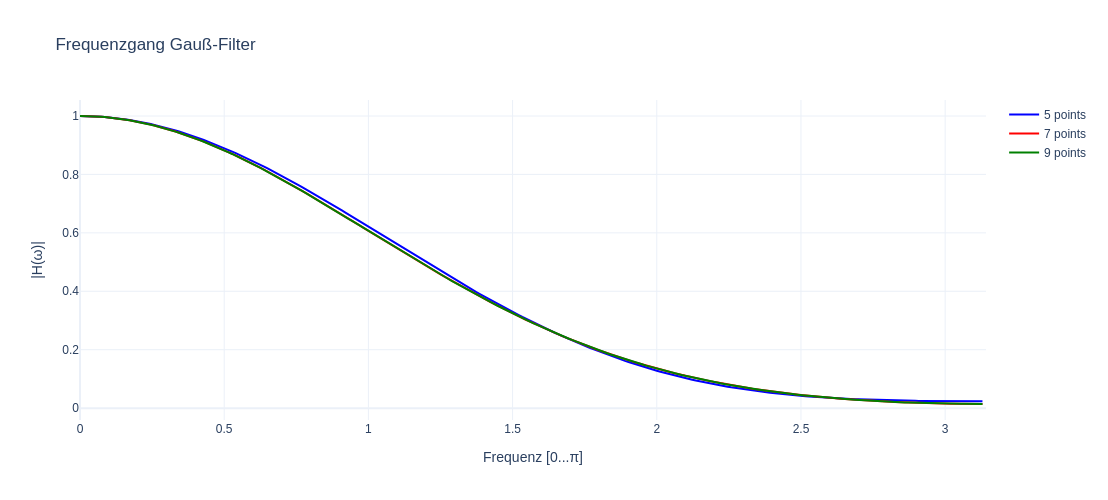

In [26]:
sigma = 1.0
lengths = [5, 7, 9]
kernels = []
H_list_c = []
labels_c = []

# FFT-Vorbereitung (512 Punkte wie im MATLAB Skript)
# Wir plotten nur die erste Hälfte (0 bis pi)
w_fft = np.linspace(0, 2*np.pi, 512, endpoint=False)
w_half = w_fft[:256] 

for n in lengths:
    # 1. Kernel erstellen (analog zu fspecial)
    g = signal.windows.gaussian(n, std=sigma)
    g /= np.sum(g) # Normalisieren auf DC-Gain = 1
    kernels.append(g)
    labels_c.append(f'{n} points')
    
    # 2. Frequenzgang berechnen
    H = np.fft.fft(g, 512)
    H_list_c.append(H[:256]) # Nur positive Frequenzen speichern

# Plot 1: Impulsantworten h(n) (Visualisierung der Glockenkurve)
# Dies machen wir manuell, da unsere Helper-Funktion nur Frequenzgänge plottet
fig_imp = go.Figure()
for i, g in enumerate(kernels):
    # Zentrierte Darstellung (Index relativ zur Mitte)
    x_centered = np.arange(len(g)) - len(g)//2
    fig_imp.add_trace(go.Scatter(x=x_centered, y=g, mode='lines+markers', name=labels_c[i]))
fig_imp.update_layout(title="Impulsantwort h(n) der Gauß-Filter", xaxis_title="n (zentriert)", height=400, width=800)
fig_imp.show()

# Plot 2: Frequenzgänge |H(w)| (Mit unserer Helper-Funktion)
plot_frequency_responses(w_half, H_list_c, labels_c, "Frequenzgang Gauß-Filter")

## Teil 2: Auswirkung auf ein Signal/Misch-Sinus-Testsignal

Audio 'handel.wav' geladen: 8192 Hz, 16384 Samples.


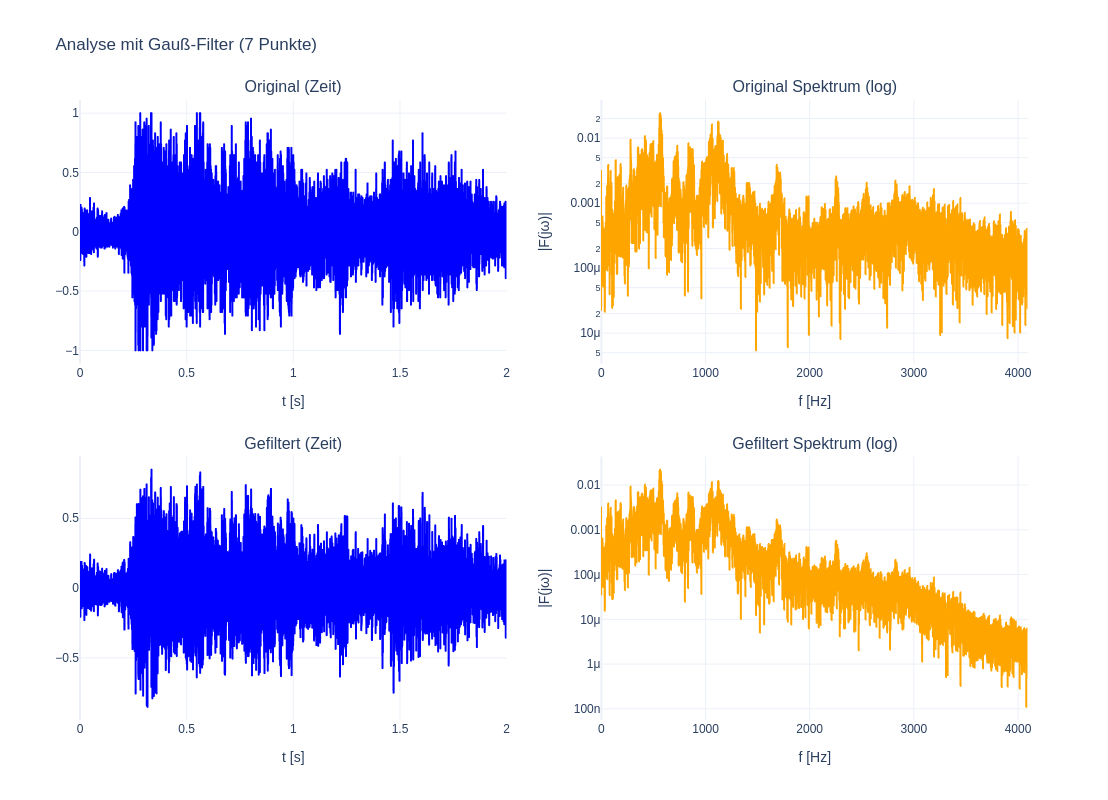

In [27]:
# 1. Signal laden (mit Fallback)
try:
    fs_wav, data = wavfile.read('handel.wav')
    
    # Konvertierung zu Float und Normalisierung (-1 bis 1)
    # wavfile liest oft Integers, MATLAB rechnet mit Floats
    sig_c = data.astype(float)
    sig_c = sig_c / np.max(np.abs(sig_c))
    
    # Auf 2 Sekunden kürzen (gemäß Aufgabe)
    sig_c = sig_c[:int(2.0*fs_wav)]
    t_c = np.arange(len(sig_c)) / fs_wav
    print(f"Audio 'handel.wav' geladen: {fs_wav} Hz, {len(sig_c)} Samples.")
    
except FileNotFoundError:
    print("Warnung: 'handel.wav' nicht gefunden. Nutze synthetisches Signal.")
    fs_wav = 100.0
    t_c, sig_c = get_test_signal(fs_wav)

# 2. Filterung (Wir nutzen den 7-Punkte Kernel aus Teil 1)
# kernels[1] entspricht der Länge 7
sig_gauss_filt = signal.lfilter(kernels[1], 1, sig_c)

# 3. Analyse Plotten (Mit unserer Helper-Funktion)
# Das Diagramm ist interaktiv, Sie können im Spektrum reinzoomen.
plot_signal_analysis(t_c, sig_c, sig_gauss_filt, fs_wav, "Analyse mit Gauß-Filter (7 Punkte)")